
# Forecasting Stock Prices Using ARIMA & Prophet

## Project Overview
This project focuses on forecasting Tesla stock prices using Time Series Forecasting techniques:
- ARIMA
- Prophet

## Contents:
- Data preprocessing
- EDA
- Stationarity testing
- Forecasting
- Model evaluation
- Dashboard visualization

## Group Members
1. Samaa Shafqat
2. Hussain Raza Naqvi
3. Kiran Sadaf
4. Humayun Saeed
5. Sabeen Tahir



# 1. Import Libraries


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error, mean_absolute_error

from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')



# 2. Load Dataset

In [2]:

df = pd.read_csv(r"C:\Users\Lenovo\Downloads\TSLA.csv")
df.head()


,Date,open,high,low,close,adjclose,volume,ingested_at_utc
0,2016-01-04,15.381333,15.425333,14.600000,14.894000,14.894000,102406500,2026-05-16 06:28:10.076536+00:00
1,2016-01-05,15.090667,15.126000,14.666667,14.895333,14.895333,47802000,2026-05-16 06:28:10.076536+00:00
2,2016-01-06,14.666667,14.670000,14.398667,14.602667,14.602667,56686500,2026-05-16 06:28:10.076536+00:00
3,2016-01-07,14.279333,14.562667,14.244667,14.376667,14.376667,53314500,2026-05-16 06:28:10.076536+00:00
4,2016-01-08,14.524000,14.696000,14.051333,14.066667,14.066667,54421500,2026-05-16 06:28:10.076536+00:00



# 3. Dataset Exploration


In [3]:

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


Shape: (2607, 8)

Columns:
Index(['Date', 'open', 'high', 'low', 'close', 'adjclose', 'volume',
       'ingested_at_utc'],
      dtype='object')

Missing Values:
Date               0
open               0
high               0
low                0
close              0
adjclose           0
volume             0
ingested_at_utc    0
dtype: int64

Duplicate Rows: 0



# 4. Data Preprocessing


In [8]:
#here we will check; Missing timestamps and Inconsistent frequency
df.index = pd.to_datetime(df.index)

df = df.asfreq('D')

df['close'].fillna(method='ffill', inplace=True)

df.head()


,open,high,low,close,adjclose,volume,ingested_at_utc
Date,,,,,,,
2016-01-04,15.381333,15.425333,14.600000,14.894000,14.894000,102406500.0,2026-05-16 06:28:10.076536+00:00
2016-01-05,15.090667,15.126000,14.666667,14.895333,14.895333,47802000.0,2026-05-16 06:28:10.076536+00:00
2016-01-06,14.666667,14.670000,14.398667,14.602667,14.602667,56686500.0,2026-05-16 06:28:10.076536+00:00
2016-01-07,14.279333,14.562667,14.244667,14.376667,14.376667,53314500.0,2026-05-16 06:28:10.076536+00:00
2016-01-08,14.524000,14.696000,14.051333,14.066667,14.066667,54421500.0,2026-05-16 06:28:10.076536+00:00



# 5. Exploratory Data Analysis (EDA)


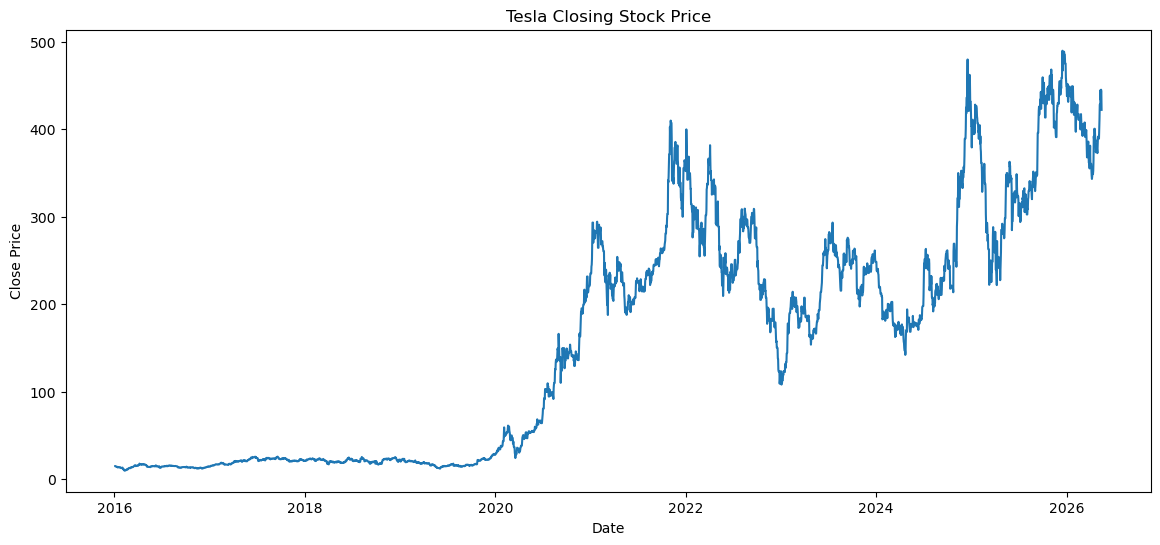

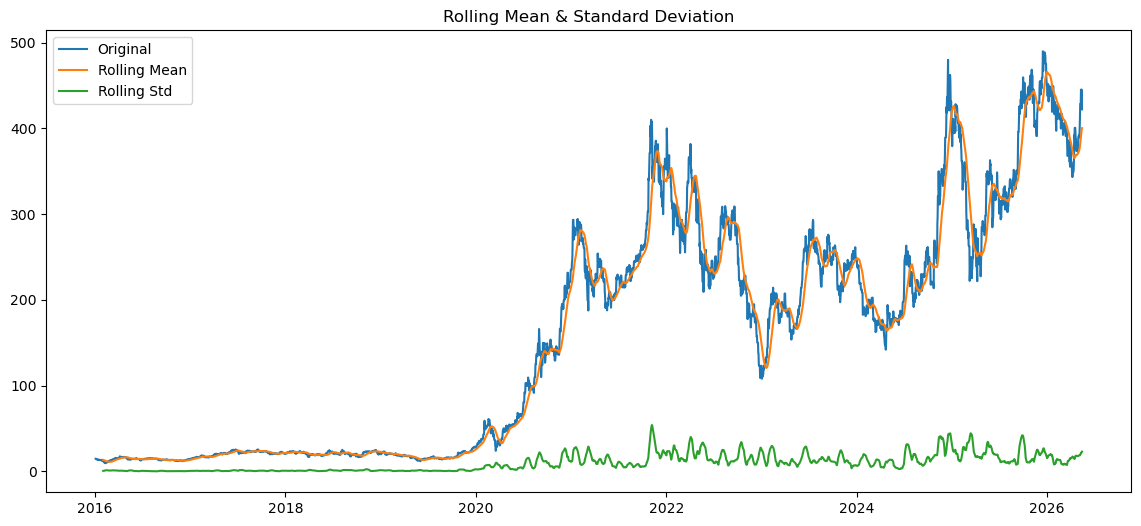

In [12]:
#here outliers will be determined visually using the stock price trend plot and rolling statistics plot
plt.figure(figsize=(14,6))
plt.plot(df['close'])
plt.title('Tesla Closing Stock Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()


rolling_mean = df['close'].rolling(window=30).mean()
rolling_std = df['close'].rolling(window=30).std()

plt.figure(figsize=(14,6))
plt.plot(df['close'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.title('Rolling Mean & Standard Deviation')
plt.show()


# 6. Seasonal Decomposition

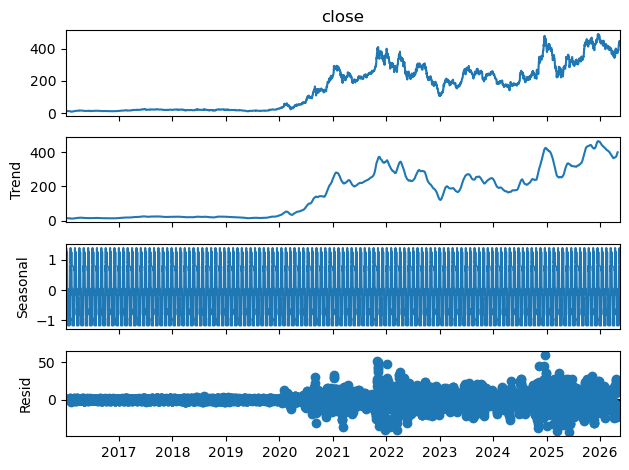

In [19]:

decompose = seasonal_decompose(df['close'].dropna(), model='additive', period=30)
decompose.plot()
plt.show()



# 7. ADF Test for Stationarity


In [13]:

result = adfuller(df['close'].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is Non-Stationary")


ADF Statistic: -1.0454644232158472
p-value: 0.7363233277684186
Data is Non-Stationary



# 8. Differencing (Stationarity Adjustments)


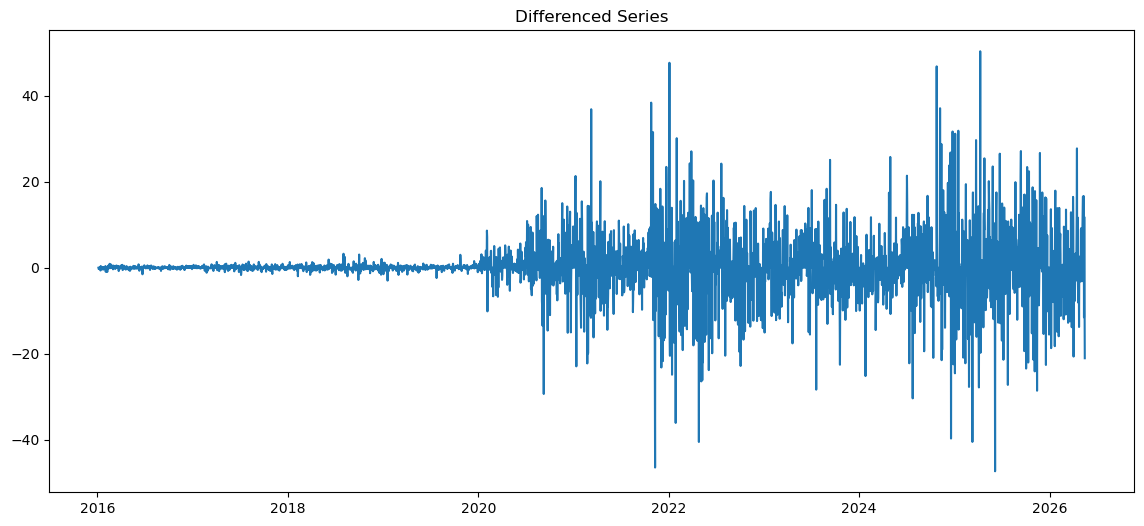

In [15]:
#Removes trend and makes data stationary
df_diff = df['close'].diff().dropna()

plt.figure(figsize=(14,6))
plt.plot(df_diff)
plt.title('Differenced Series')
plt.show()



# 9. ACF and PACF Plots


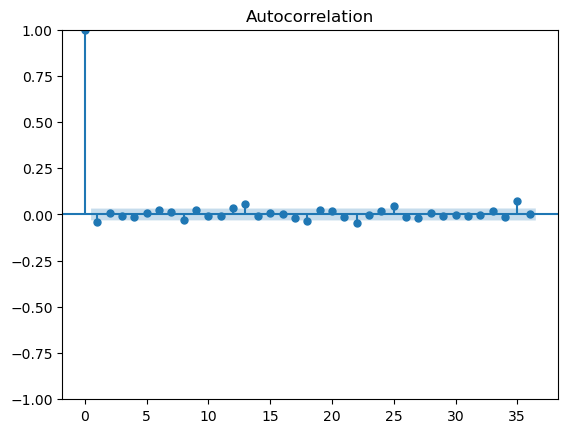

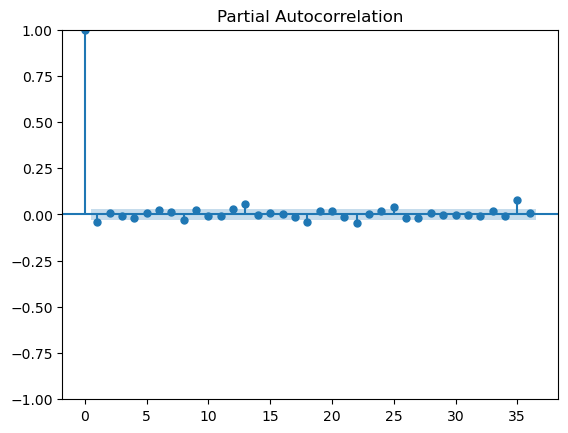

In [17]:

plot_acf(df_diff)
plt.show()

plot_pacf(df_diff)
plt.show()


# 10. Feature Engineering

In [16]:
df['Lag_1'] = df['close'].shift(1)

df['Rolling_Mean_7'] = df['close'].rolling(window=7).mean()

df['Rolling_STD_7'] = df['close'].rolling(window=7).std()

df.head()

,open,high,low,close,adjclose,volume,ingested_at_utc,Lag_1,Rolling_Mean_7,Rolling_STD_7
Date,,,,,,,,,,
2016-01-04,15.381333,15.425333,14.600000,14.894000,14.894000,102406500.0,2026-05-16 06:28:10.076536+00:00,NaN,NaN,NaN
2016-01-05,15.090667,15.126000,14.666667,14.895333,14.895333,47802000.0,2026-05-16 06:28:10.076536+00:00,14.894000,NaN,NaN
2016-01-06,14.666667,14.670000,14.398667,14.602667,14.602667,56686500.0,2026-05-16 06:28:10.076536+00:00,14.895333,NaN,NaN
2016-01-07,14.279333,14.562667,14.244667,14.376667,14.376667,53314500.0,2026-05-16 06:28:10.076536+00:00,14.602667,NaN,NaN
2016-01-08,14.524000,14.696000,14.051333,14.066667,14.066667,54421500.0,2026-05-16 06:28:10.076536+00:00,14.376667,NaN,NaN



# 11. Train-Test Split


In [21]:
#The dataset was divided into training and testing sets using an 80-20 split.
train_size = int(len(df) * 0.8)

train = df['close'][:train_size]
test = df['close'][train_size:]

print("Train Size:", len(train))
print("Test Size:", len(test))


Train Size: 3028
Test Size: 757



# 12. ARIMA Model



ARIMA Parameters:
- p selected using PACF
- d selected using differencing
- q selected using ACF


In [22]:

arima_model = ARIMA(train, order=(1,1,1))
arima_fitted = arima_model.fit()

arima_forecast = arima_fitted.forecast(steps=len(test))



# 13. Prophet Model


In [24]:

prophet_df = df.reset_index()[['Date', 'close']]
prophet_df.columns = ['ds', 'y']

train_prophet = prophet_df[:train_size]
test_prophet = prophet_df[train_size:]

prophet_model = Prophet()
prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(periods=len(test_prophet))

forecast = prophet_model.predict(future)

prophet_forecast = forecast['yhat'][-len(test_prophet):].values


05:01:47 - cmdstanpy - INFO - Chain [1] start processing
05:01:48 - cmdstanpy - INFO - Chain [1] done processing



# 14. Model Evaluation


In [25]:

# ARIMA Metrics
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mae = mean_absolute_error(test, arima_forecast)
arima_mape = np.mean(np.abs((test - arima_forecast) / test)) * 100

# Prophet Metrics
prophet_rmse = np.sqrt(mean_squared_error(test_prophet['y'], prophet_forecast))
prophet_mae = mean_absolute_error(test_prophet['y'], prophet_forecast)
prophet_mape = np.mean(np.abs((test_prophet['y'] - prophet_forecast) / test_prophet['y'])) * 100

results = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet'],
    'RMSE': [arima_rmse, prophet_rmse],
    'MAE': [arima_mae, prophet_mae],
    'MAPE': [arima_mape, prophet_mape]
})

results


,Model,RMSE,MAE,MAPE
0,ARIMA,199.915842,178.517451,50.091445
1,Prophet,167.589581,141.286291,38.081226



# 15. Actual vs Predicted Plot


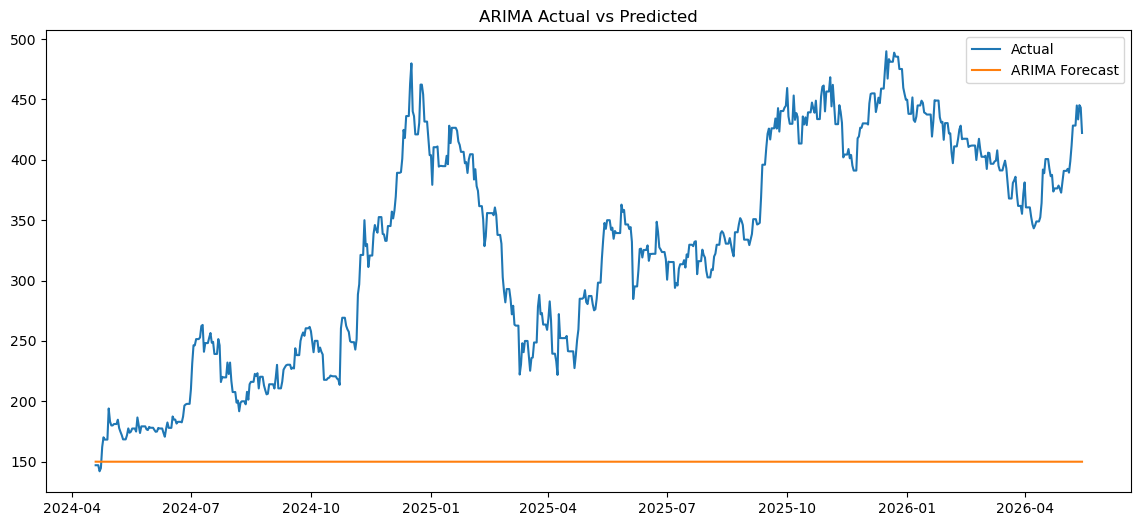

In [26]:

plt.figure(figsize=(14,6))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.legend()

plt.title('ARIMA Actual vs Predicted')
plt.show()


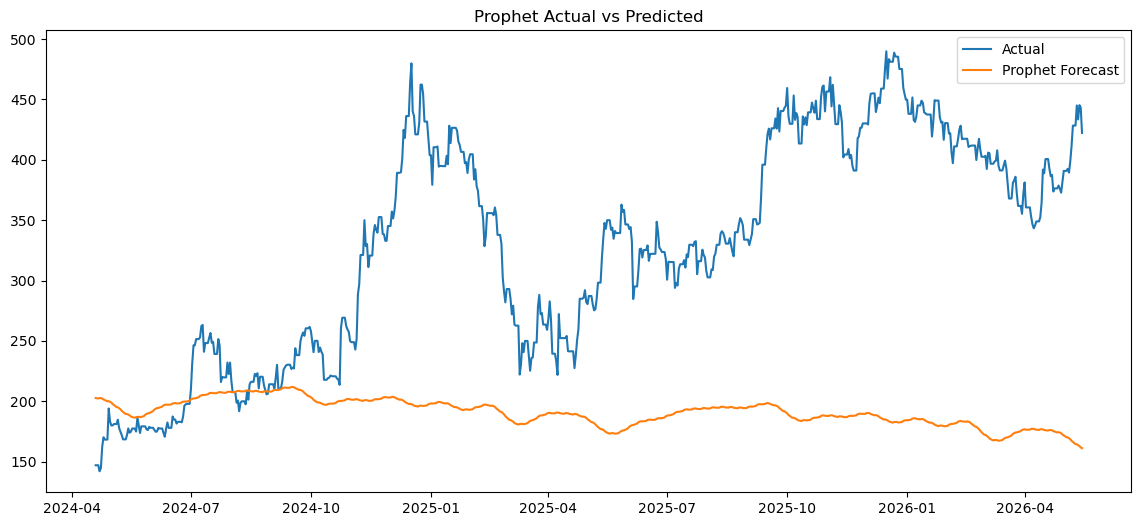

In [27]:

plt.figure(figsize=(14,6))

plt.plot(test_prophet['ds'], test_prophet['y'], label='Actual')
plt.plot(test_prophet['ds'], prophet_forecast, label='Prophet Forecast')
plt.legend()

plt.title('Prophet Actual vs Predicted')
plt.show()



# 16. Residual Analysis


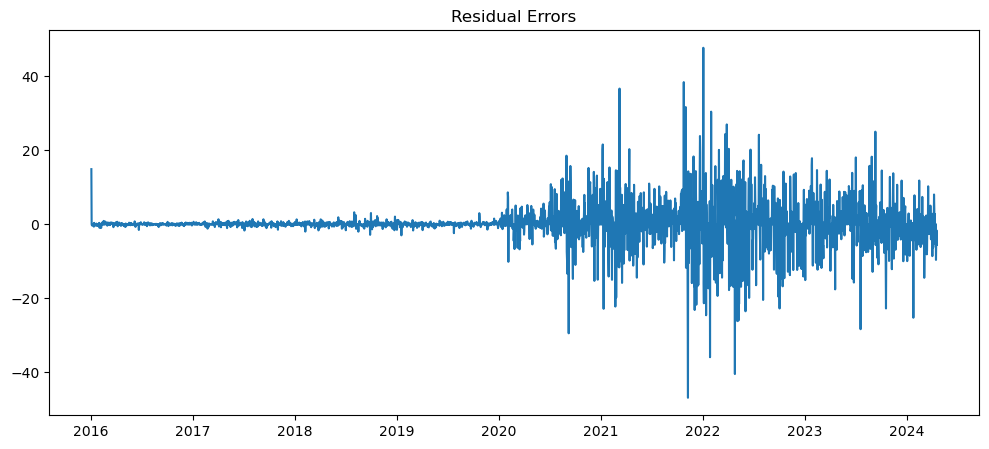

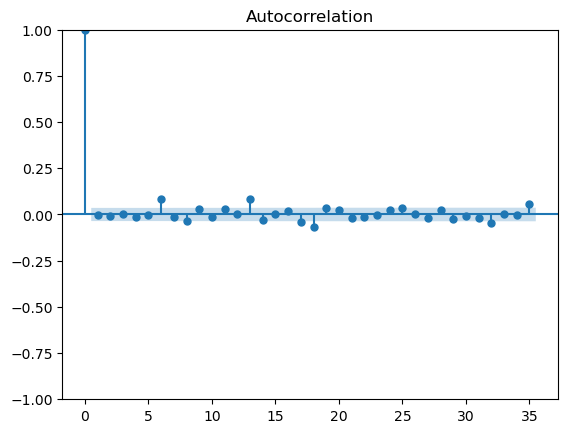

In [28]:

residuals = arima_fitted.resid

plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title('Residual Errors')
plt.show()

plot_acf(residuals)
plt.show()



# 17. Future Forecasting (3months)


In [48]:

final_model = ARIMA(df['close'], order=(1,1,1))
final_model_fit = final_model.fit()

# 3 months = 90days
future_forecast = final_model_fit.get_forecast(steps=90)

future_forecast_series = future_forecast.predicted_mean
conf_int = future_forecast.conf_int()


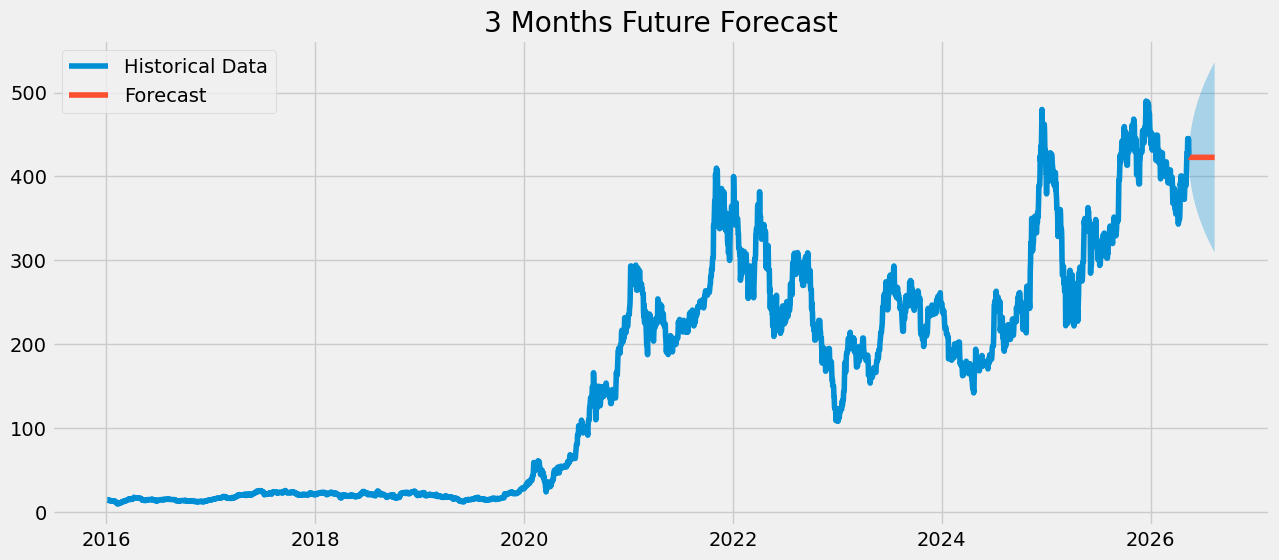

In [49]:

plt.figure(figsize=(14,6))

plt.plot(df.index, df['close'], label='Historical Data')
plt.plot(future_forecast_series.index, future_forecast_series, label='Forecast')

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3
)

plt.legend()
plt.title('3 Months Future Forecast')
plt.show()



# 18. Plotly Dashboard


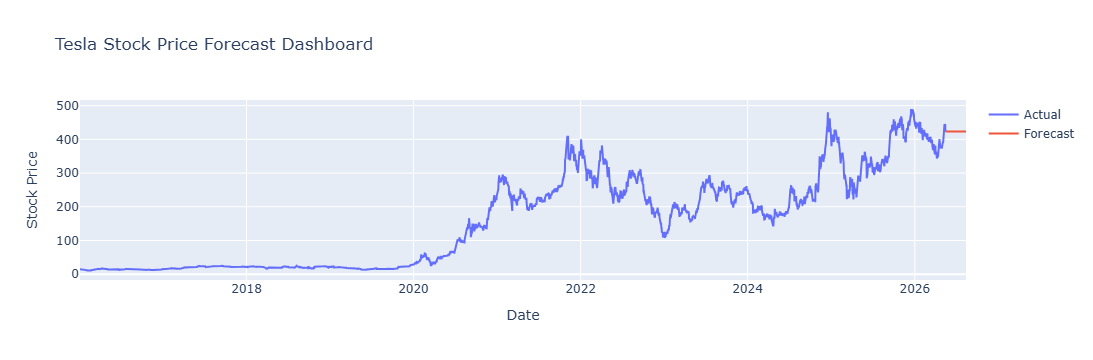

In [50]:

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df.index,
    y=df['close'],
    mode='lines',
    name='Actual'
))

fig.add_trace(go.Scatter(
    x=future_forecast_series.index,
    y=future_forecast_series,
    mode='lines',
    name='Forecast'
))

fig.update_layout(
    title='Tesla Stock Price Forecast Dashboard',
    xaxis_title='Date',
    yaxis_title='Stock Price'
)

fig.show()
